Kelompok 2

Muhammad Akmal Abiyu 25031554100

Rajendra Alif Abhyasa Cahyono 25031554137

# **Exercise 3**

Scraping HTML

In [22]:
# @title
import requests
from bs4 import BeautifulSoup
import pandas as pd

html_quotes = []
for page in range(1, 6):
    webrequest = requests.get(f'https://quotes.toscrape.com/page/{page}/')
    soup = BeautifulSoup(webrequest.text, 'html.parser')
    for q in soup.find_all('div', {'class': 'quote'}):
        text = q.find('span', {'class': 'text'}).text
        author = q.find('small', {'class': 'author'}).text
        html_quotes.append({'text': text, 'author': author, 'source': 'html'})

html_quotes

[{'text': '“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”',
  'author': 'Albert Einstein',
  'source': 'html'},
 {'text': '“It is our choices, Harry, that show what we truly are, far more than our abilities.”',
  'author': 'J.K. Rowling',
  'source': 'html'},
 {'text': '“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”',
  'author': 'Albert Einstein',
  'source': 'html'},
 {'text': '“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”',
  'author': 'Jane Austen',
  'source': 'html'},
 {'text': "“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",
  'author': 'Marilyn Monroe',
  'source': 'html'},
 {'text': '“Try not to become a man of success. Rather become a man of value.”',
  'author': 'Albert Einstein',
  'source': 'html'},

Scraping API

In [23]:
# @title
apirequest = requests.get('https://dummyjson.com/quotes', params={'limit': 50})
data = apirequest.json()

api_quotes = [{'text': q['quote'], 'author': q['author'], 'source': 'api'} for q in data['quotes']]

api_quotes

[{'text': 'Your heart is the size of an ocean. Go find yourself in its hidden depths.',
  'author': 'Rumi',
  'source': 'api'},
 {'text': 'The Bay of Bengal is hit frequently by cyclones. The months of November and May, in particular, are dangerous in this regard.',
  'author': 'Abdul Kalam',
  'source': 'api'},
 {'text': 'Thinking is the capital, Enterprise is the way, Hard Work is the solution.',
  'author': 'Abdul Kalam',
  'source': 'api'},
 {'text': "If You Can'T Make It Good, At Least Make It Look Good.",
  'author': 'Bill Gates',
  'source': 'api'},
 {'text': "Heart be brave. If you cannot be brave, just go. Love's glory is not a small thing.",
  'author': 'Rumi',
  'source': 'api'},
 {'text': 'It is bad for a young man to sin; but it is worse for an old man to sin.',
  'author': 'Abu Bakr (R.A)',
  'source': 'api'},
 {'text': 'If You Are Out To Describe The Truth, Leave Elegance To The Tailor.',
  'author': 'Albert Einstein',
  'source': 'api'},
 {'text': 'O man you are busy wo

Menjadikan 1 df

In [24]:
# @title
df = pd.DataFrame(html_quotes + api_quotes)
df.head(15)

,text,author,source
0,“The world as we have created it is a process ...,Albert Einstein,html
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,html
2,“There are only two ways to live your life. On...,Albert Einstein,html
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,html
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,html
5,“Try not to become a man of success. Rather be...,Albert Einstein,html
6,“It is better to be hated for what you are tha...,André Gide,html
7,"“I have not failed. I've just found 10,000 way...",Thomas A. Edison,html
8,“A woman is like a tea bag; you never know how...,Eleanor Roosevelt,html
9,"“A day without sunshine is like, you know, nig...",Steve Martin,html


# **Exercise 4**

Pre-processing teks

In [25]:
# @title
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

def remove_html(text):
    html_pattern = re.compile('<.*?>')
    return html_pattern.sub(r'', text)

def remove_rls(text):
    text = re.sub(r'https?\/\/S+', '', str(text))
    text = re.sub(r'http\S+', '', str(text))
    text = re.sub(r'www\S+', '', str(text))
    text = re.sub(r'\S+@\S+', '', str(text))
    return text

punc = string.punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', punc))

sw = set(stopwords.words('english'))
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in sw])

ps = PorterStemmer()
def stem_text(text):
    return " ".join([ps.stem(word) for word in str(text).split()])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
# @title
df['rm_html'] = df['text'].apply(remove_html)
df['rm_url'] = df['rm_html'].apply(remove_rls)
df['lower_case'] = df['rm_url'].str.lower()
df['rm_punc'] = df['lower_case'].apply(remove_punctuation)
df['rm_stopwords'] = df['rm_punc'].apply(remove_stopwords)
df['stem'] = df['rm_stopwords'].apply(stem_text)

df.rename(columns={'stem': 'prepro'}, inplace=True)
df[['text', 'prepro']].head(15)

,text,prepro
0,“The world as we have created it is a process ...,“the world creat process think cannot chang wi...
1,"“It is our choices, Harry, that show what we t...",“it choic harri show truli far abilities”
2,“There are only two ways to live your life. On...,“there two way live life one though noth mirac...
3,"“The person, be it gentleman or lady, who has ...",“the person gentleman ladi pleasur good novel ...
4,"“Imperfection is beauty, madness is genius and...",“imperfect beauti mad geniu better absolut rid...
5,“Try not to become a man of success. Rather be...,“tri becom man success rather becom man value”
6,“It is better to be hated for what you are tha...,“it better hate love not”
7,"“I have not failed. I've just found 10,000 way...",“i fail ive found 10000 way wont work”
8,“A woman is like a tea bag; you never know how...,“a woman like tea bag never know strong hot wa...
9,"“A day without sunshine is like, you know, nig...",“a day without sunshin like know night”


# **Word Cloud dari kata yang tersisa setelah preprocessing**

In [27]:
# @title
df.to_csv('quotes_preprocessed.csv', index=False)

In [28]:
# @title
!pip install wordcloud

Eksekusi Word Cloud

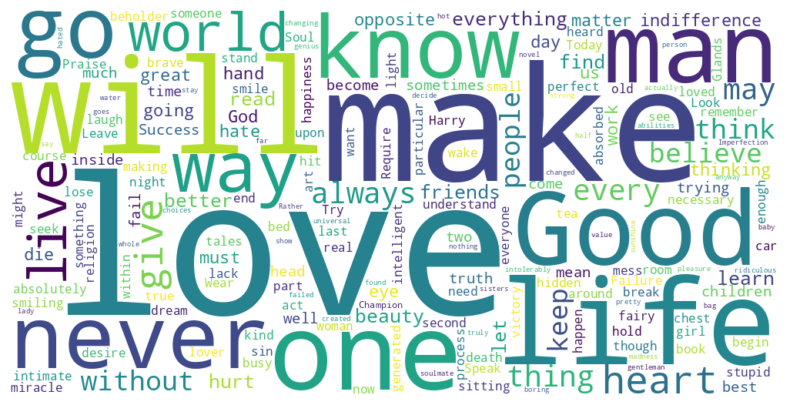

In [29]:
# @title
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_raw = ' '.join(df['text'].dropna().astype(str))

wordcloud_raw = WordCloud(width=1000, height=500, background_color='white', max_words=200).generate(text_raw)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_raw, interpolation='bilinear')
plt.axis('off')
plt.show()

## **Exercise 5**

Word2Vec

In [30]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

df = pd.read_csv('quotes_preprocessed.csv')
df = df.dropna().reset_index().drop(columns=['index'])
df_pre = df['prepro']
df_pre.info()

<class 'pandas.core.series.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: prepro
Non-Null Count  Dtype 
--------------  ----- 
100 non-null    object
dtypes: object(1)
memory usage: 932.0+ bytes


In [31]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df_pre)
df_FE = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df_FE

,10000,abilities,about,absolut,absorb,accid,act,actual,admit,adventure,...,would,year,yet,you,youd,youer,youll,young,your,yourself
0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.396587,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.632418,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
97,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Tokenize Sentence

In [32]:
import warnings
warnings.filterwarnings(action='ignore')

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [33]:
from nltk import word_tokenize
from tqdm import tqdm

sentences = [word_tokenize(text.lower()) for text in tqdm(df_pre)]
sentences

100%|██████████| 100/100 [00:00<00:00, 2787.28it/s]


[['“',
  'the',
  'world',
  'creat',
  'process',
  'think',
  'can',
  'not',
  'chang',
  'without',
  'chang',
  'thinking',
  '”'],
 ['“', 'it', 'choic', 'harri', 'show', 'truli', 'far', 'abilities', '”'],
 ['“',
  'there',
  'two',
  'way',
  'live',
  'life',
  'one',
  'though',
  'noth',
  'miracl',
  'though',
  'everyth',
  'miracle',
  '”'],
 ['“',
  'the',
  'person',
  'gentleman',
  'ladi',
  'pleasur',
  'good',
  'novel',
  'must',
  'intoler',
  'stupid',
  '”'],
 ['“',
  'imperfect',
  'beauti',
  'mad',
  'geniu',
  'better',
  'absolut',
  'ridicul',
  'absolut',
  'boring',
  '”'],
 ['“',
  'tri',
  'becom',
  'man',
  'success',
  'rather',
  'becom',
  'man',
  'value',
  '”'],
 ['“', 'it', 'better', 'hate', 'love', 'not', '”'],
 ['“', 'i', 'fail', 'ive', 'found', '10000', 'way', 'wont', 'work', '”'],
 ['“',
  'a',
  'woman',
  'like',
  'tea',
  'bag',
  'never',
  'know',
  'strong',
  'hot',
  'water',
  '”'],
 ['“', 'a', 'day', 'without', 'sunshin', 'like', 

Fastext Model


In [34]:
!pip install gensim

!pip install umap-learn

Word2Vec Model

In [35]:
import gensim.models
model = gensim.models.Word2Vec(sentences, min_count=1, vector_size=100, window=5, sg=0)

In [36]:
model.save('quotes.w2v')

In [37]:
model = gensim.models.Word2Vec.load('quotes.w2v')

In [38]:
w2v = model.wv
w2v.index_to_key[:10]

['”', '“', 'love', 'make', 'go', 'life', 'like', 'dont', 'know', 'good']

In [39]:
w2v.vectors.shape, w2v.vector_size

((504, 100), 100)

In [40]:
w2v.similar_by_key('love')

[('need', 0.3951999843120575),
 ('jojen', 0.27544787526130676),
 ('thousand', 0.26107001304626465),
 ('whole', 0.25892388820648193),
 ('tailor', 0.24761243164539337),
 ('tri', 0.23534785211086273),
 ('know', 0.2204660177230835),
 ('chest', 0.2181725949048996),
 ('youd', 0.21752682328224182),
 ('great', 0.2114938199520111)]

In [41]:
import numpy as np
def get_document_vector(tokens, model):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(valid_vectors, axis=0)
X_features = np.array([get_document_vector(doc, model) for doc in sentences])
pd.DataFrame(X_features)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.002947,0.002307,0.001567,0.000861,0.001387,-0.003237,0.002673,0.001821,-0.000845,-0.000362,...,0.002691,0.002061,-0.001618,-0.000197,0.002680,0.001650,-0.000417,0.001273,-0.002277,0.001689
1,-0.001867,0.001105,0.003150,0.001910,-0.000744,-0.000478,-0.000155,0.001884,0.000780,-0.000215,...,0.000658,-0.000859,0.000791,-0.000327,0.002065,0.003525,-0.000302,-0.001088,-0.001957,0.004685
2,-0.002463,-0.001409,-0.001116,0.000918,0.001451,-0.003562,-0.000292,0.003541,-0.001933,-0.002137,...,0.002052,0.002016,-0.001048,0.002397,-0.001166,0.003764,-0.002223,0.000185,-0.000272,0.001024
3,-0.002213,0.000462,0.001832,0.003340,-0.000084,-0.003112,0.002748,0.002136,-0.001772,-0.002675,...,0.001372,-0.001144,0.002307,0.001974,0.002360,0.002698,-0.002144,-0.002114,-0.001228,-0.001725
4,-0.001040,-0.001858,-0.001453,-0.001005,-0.002678,-0.002787,0.000851,0.000431,0.000624,-0.000382,...,-0.000597,-0.000759,0.000278,-0.003274,0.002172,0.002072,-0.003552,-0.004722,-0.000837,0.000432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-0.001460,0.000981,-0.005862,-0.000869,-0.001562,-0.001409,0.000386,-0.002145,0.004276,0.004593,...,0.005809,0.001168,0.000045,-0.000360,-0.002282,0.001097,-0.003357,-0.002769,0.001269,0.000057
96,-0.002936,-0.002128,-0.004059,-0.002033,0.000669,0.003611,0.003337,0.000907,-0.001492,-0.004578,...,0.005054,0.000240,-0.004405,0.000395,0.006310,0.002869,0.001185,-0.002900,0.006013,0.000675
97,-0.001885,0.003157,-0.001061,-0.001275,-0.004277,-0.001980,-0.000311,0.000924,0.001260,-0.003440,...,0.001625,0.001304,-0.004795,0.000176,0.005679,-0.001402,0.001485,-0.004396,0.001455,-0.002155
98,-0.000297,0.002035,0.004563,0.002459,-0.003581,0.002001,0.000737,0.002842,-0.001148,0.003735,...,0.002823,-0.004525,0.004998,-0.004772,0.001144,-0.002222,0.001970,-0.000341,-0.000728,-0.001328


Visualize

In [42]:
from umap import UMAP
import numpy as np
import plotly.express as px

X = UMAP().fit_transform(w2v.vectors)

df2 = pd.DataFrame(X, columns=['umap1', 'umap2'])
df2['word'] = w2v.index_to_key

fig = px.scatter(df2, x='umap1', y='umap2', text='word')
fig.update_traces(textposition='top center')
fig.update_layout(height = 800,
                  title_text = 'Word2Vec Visualization')
fig.show()

FasText Visualize

In [43]:
import gensim.models
#build model
model_fasttext = gensim.models.FastText(sentences, min_count=1,
                                        vector_size=100, window=5,
                                        min_n=3, max_n=6,
                                        sg=1, epochs=10)

model_fasttext.save('quotes.fasttext')
model_fasttext = gensim.models.Word2Vec.load('quotes.fasttext')
fastext = model_fasttext.wv
fastext.index_to_key[:10]

['”', '“', 'love', 'make', 'go', 'life', 'like', 'dont', 'know', 'good']

In [44]:
fastext.vectors.shape

(504, 100)

In [45]:
fastext.similar_by_key('"')

[('na', -0.0025063601788133383),
 ('onli', -0.008054327219724655),
 ('judg', -0.015460062772035599),
 ('ani', -0.042358800768852234),
 ('we', -0.045617785304784775),
 ('logic', -0.04694515839219093),
 ('left', -0.04941899701952934),
 ('value', -0.051080357283353806),
 ('hundr', -0.05351557582616806),
 ('abilities', -0.05423432216048241)]

In [46]:
import numpy as np
def get_document_vector(tokens, model):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(valid_vectors, axis=0)
X_features = np.array([get_document_vector(doc, model_fasttext) for doc in sentences])
pd.DataFrame(X_features)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.003657,-0.007755,-0.012335,0.000803,-0.021764,-0.008623,0.011733,0.024849,-0.013173,-0.018139,...,-0.008263,-0.009911,-0.013365,-0.001616,0.010191,0.005905,-0.007309,0.002569,-0.004867,0.013892
1,-0.003072,-0.006207,-0.007700,-0.000145,-0.017571,-0.006223,0.008654,0.019372,-0.008593,-0.013304,...,-0.005890,-0.007564,-0.009505,-0.000680,0.008192,0.004783,-0.005338,0.002010,-0.003772,0.010254
2,-0.004087,-0.007286,-0.011299,0.000274,-0.020171,-0.008027,0.010464,0.024402,-0.012020,-0.017844,...,-0.007209,-0.008022,-0.011719,-0.000860,0.010680,0.005267,-0.006424,0.001415,-0.004153,0.013334
3,-0.002618,-0.006204,-0.008418,0.001135,-0.015928,-0.006793,0.009691,0.018364,-0.009174,-0.013875,...,-0.005512,-0.007540,-0.009141,-0.000643,0.008009,0.004397,-0.004696,0.001054,-0.003720,0.010474
4,-0.003659,-0.006073,-0.008704,0.000981,-0.017008,-0.007251,0.008145,0.018922,-0.009769,-0.014089,...,-0.005656,-0.007407,-0.009663,-0.001902,0.009253,0.004775,-0.005177,0.001571,-0.003079,0.011322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-0.002779,-0.004197,-0.007384,-0.000240,-0.010114,-0.004802,0.007269,0.013267,-0.007937,-0.010244,...,-0.003070,-0.004357,-0.005878,0.001638,0.006244,0.003363,-0.005354,0.001374,-0.004099,0.006721
96,-0.003093,-0.005216,-0.007450,0.000073,-0.012866,-0.003297,0.005813,0.013335,-0.006992,-0.011198,...,-0.004772,-0.004817,-0.007095,-0.000566,0.005073,0.002843,-0.003431,0.000353,-0.002418,0.007222
97,-0.004936,-0.008170,-0.011267,-0.000076,-0.019402,-0.007474,0.010118,0.022080,-0.010519,-0.017867,...,-0.007584,-0.008095,-0.011518,-0.001365,0.009790,0.005618,-0.006510,0.000481,-0.003318,0.012945
98,-0.001113,-0.003603,-0.006743,0.000530,-0.011958,-0.001876,0.006652,0.013132,-0.006501,-0.010627,...,-0.005014,-0.005324,-0.006128,0.000167,0.006004,0.003195,-0.004188,0.000169,-0.002814,0.008366


In [47]:
X = UMAP().fit_transform(fastext.vectors)

df2 = pd.DataFrame(X, columns=['umap1', 'umap2'])
df2['word'] = fastext.index_to_key

fig = px.scatter(df2, x='umap1', y='umap2', text='word')
fig.update_traces(textposition='top center')
fig.update_layout(height = 800,
                  title_text = 'fastext Visualization')
fig.show()